In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('anxiety_depression_data.csv', keep_default_na=False, na_values=[])
df.head()

,Age,Gender,Education_Level,Employment_Status,Sleep_Hours,Physical_Activity_Hrs,Social_Support_Score,Anxiety_Score,Depression_Score,Stress_Level,...,Chronic_Illnesses,Medication_Use,Therapy,Meditation,Substance_Use,Financial_Stress,Work_Stress,Self_Esteem_Score,Life_Satisfaction_Score,Loneliness_Score
0,56,Male,Bachelor's,Unemployed,6.0,0.4,3,4,2,9,...,0,None,0,1,None,4,3,7,5,1
1,69,Female,Bachelor's,Retired,8.8,2.8,6,18,7,6,...,0,None,1,0,None,1,4,7,4,6
2,46,Female,Master's,Employed,5.3,1.6,5,5,13,8,...,0,None,0,1,None,8,7,8,1,1
3,32,Female,High School,Unemployed,8.8,0.5,4,6,3,4,...,1,None,0,0,None,7,4,8,4,4
4,60,Female,Bachelor's,Retired,7.2,0.7,2,7,15,3,...,0,None,1,1,Frequent,8,9,5,7,7


In [3]:
print("Shape (rows, columns):", df.shape)

print("\nColumn Data Types:")
print(df.dtypes)

print("\nMissing Values Per Column:")
print(df.isnull().sum())

print("\nNumber of Duplicate Rows:", df.duplicated().sum())

Shape (rows, columns): (1200, 21)

Column Data Types:
Age                                int64
Gender                            object
Education_Level                   object
Employment_Status                 object
Sleep_Hours                      float64
Physical_Activity_Hrs            float64
Social_Support_Score               int64
Anxiety_Score                      int64
Depression_Score                   int64
Stress_Level                       int64
Family_History_Mental_Illness      int64
Chronic_Illnesses                  int64
Medication_Use                    object
Therapy                            int64
Meditation                         int64
Substance_Use                     object
Financial_Stress                   int64
Work_Stress                        int64
Self_Esteem_Score                  int64
Life_Satisfaction_Score            int64
Loneliness_Score                   int64
dtype: object

Missing Values Per Column:
Age                              0
Gender  

In [4]:
df.columns

Index(['Age', 'Gender', 'Education_Level', 'Employment_Status', 'Sleep_Hours',
       'Physical_Activity_Hrs', 'Social_Support_Score', 'Anxiety_Score',
       'Depression_Score', 'Stress_Level', 'Family_History_Mental_Illness',
       'Chronic_Illnesses', 'Medication_Use', 'Therapy', 'Meditation',
       'Substance_Use', 'Financial_Stress', 'Work_Stress', 'Self_Esteem_Score',
       'Life_Satisfaction_Score', 'Loneliness_Score'],
      dtype='object')

In [5]:
df.describe()

,Age,Sleep_Hours,Physical_Activity_Hrs,Social_Support_Score,Anxiety_Score,Depression_Score,Stress_Level,Family_History_Mental_Illness,Chronic_Illnesses,Therapy,Meditation,Financial_Stress,Work_Stress,Self_Esteem_Score,Life_Satisfaction_Score,Loneliness_Score
count,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000
mean,46.317500,6.46900,2.005750,5.055000,10.470000,10.674167,5.000833,0.318333,0.26750,0.210000,0.399167,4.992500,4.889167,5.062500,5.12000,4.959167
std,16.451157,1.52955,2.037818,2.652893,5.911138,5.632889,2.538281,0.466024,0.44284,0.407478,0.489931,2.590953,2.547016,2.531587,2.56991,2.566383
min,18.000000,2.00000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000
25%,33.000000,5.40000,0.600000,3.000000,5.000000,6.000000,3.000000,0.000000,0.00000,0.000000,0.000000,3.000000,3.000000,3.000000,3.00000,3.000000
50%,46.000000,6.40000,1.400000,5.000000,10.500000,11.000000,5.000000,0.000000,0.00000,0.000000,0.000000,5.000000,5.000000,5.000000,5.00000,5.000000
75%,61.000000,7.50000,2.700000,7.000000,16.000000,15.000000,7.000000,1.000000,1.00000,0.000000,1.000000,7.000000,7.000000,7.000000,7.00000,7.000000
max,74.000000,12.40000,15.100000,9.000000,20.000000,20.000000,9.000000,1.000000,1.00000,1.000000,1.000000,9.000000,9.000000,9.000000,9.00000,9.000000


In [6]:
# --- NORMALIZE SCORES ---
df["Anxiety_norm"] = df["Anxiety_Score"] / 20
df["Depression_norm"] = df["Depression_Score"] / 20
df["Stress_norm"] = df["Stress_Level"] / 9

# --- COMPOSITE SCORE ---
df["Composite_Score"] = (
    df["Anxiety_norm"] + df["Depression_norm"] + df["Stress_norm"]
) / 3

# --- FUNCTION TO MAP RISK LEVELS ---
def get_risk_level(score):
    if score <= 0.33:
        return "Low"
    elif score <= 0.66:
        return "Moderate"
    else:
        return "High"

# --- CREATE TARGET COLUMN ---
df["mental_health_risk"] = df["Composite_Score"].apply(get_risk_level)

# --- OPTIONAL: PREVIEW RESULTS ---
df[["Anxiety_Score", "Depression_Score", "Stress_Level",
    "Composite_Score", "mental_health_risk"]].head()

,Anxiety_Score,Depression_Score,Stress_Level,Composite_Score,mental_health_risk
0,4,2,9,0.433333,Moderate
1,18,7,6,0.638889,Moderate
2,5,13,8,0.596296,Moderate
3,6,3,4,0.298148,Low
4,7,15,3,0.477778,Moderate


In [7]:
for col in ['Gender','Education_Level', 'Employment_Status', 'Medication_Use', 'Substance_Use']:
    print(f"Unique values for {col}: {df[col].unique()}")

Unique values for Gender: ['Male' 'Female' 'Non-Binary' 'Other']
Unique values for Education_Level: ["Bachelor's" "Master's" 'High School' 'Other' 'PhD']
Unique values for Employment_Status: ['Unemployed' 'Retired' 'Employed' 'Student']
Unique values for Medication_Use: ['None' 'Occasional' 'Regular']
Unique values for Substance_Use: ['None' 'Frequent' 'Occasional']


In [8]:
# List of columns with text (categorical) data
cat_cols = ['Gender', 'Education_Level', 'Employment_Status', 'Medication_Use', 'Substance_Use']

# Convert them from object to category type
df[cat_cols] = df[cat_cols].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Age                            1200 non-null   int64   
 1   Gender                         1200 non-null   category
 2   Education_Level                1200 non-null   category
 3   Employment_Status              1200 non-null   category
 4   Sleep_Hours                    1200 non-null   float64 
 5   Physical_Activity_Hrs          1200 non-null   float64 
 6   Social_Support_Score           1200 non-null   int64   
 7   Anxiety_Score                  1200 non-null   int64   
 8   Depression_Score               1200 non-null   int64   
 9   Stress_Level                   1200 non-null   int64   
 10  Family_History_Mental_Illness  1200 non-null   int64   
 11  Chronic_Illnesses              1200 non-null   int64   
 12  Medication_Use                 120

In [9]:
# Gender
gender_map = {'Male': 0, 'Female': 1, 'Non-Binary': 2, 'Other': 3}
df['Gender'] = df['Gender'].map(gender_map)

# Education_Level (assuming order: High School < Bachelor's < Master's < PhD < Other)
edu_map = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3, 'Other': 4}
df['Education_Level'] = df['Education_Level'].map(edu_map)

# Employment_Status (arbitrary numeric assignment)
emp_map = {'Unemployed': 0, 'Retired': 1, 'Employed': 2, 'Student': 3}
df['Employment_Status'] = df['Employment_Status'].map(emp_map)

# Medication_Use (ordinal)
med_map = {'None': 0, 'Occasional': 1, 'Regular': 2}
df['Medication_Use'] = df['Medication_Use'].map(med_map)

# Substance_Use (ordinal)
sub_map = {'None': 0, 'Occasional': 1, 'Frequent': 2}
df['Substance_Use'] = df['Substance_Use'].map(sub_map)
df.head()

,Age,Gender,Education_Level,Employment_Status,Sleep_Hours,Physical_Activity_Hrs,Social_Support_Score,Anxiety_Score,Depression_Score,Stress_Level,...,Financial_Stress,Work_Stress,Self_Esteem_Score,Life_Satisfaction_Score,Loneliness_Score,Anxiety_norm,Depression_norm,Stress_norm,Composite_Score,mental_health_risk
0,56,0,1,0,6.0,0.4,3,4,2,9,...,4,3,7,5,1,0.20,0.10,1.000000,0.433333,Moderate
1,69,1,1,1,8.8,2.8,6,18,7,6,...,1,4,7,4,6,0.90,0.35,0.666667,0.638889,Moderate
2,46,1,2,2,5.3,1.6,5,5,13,8,...,8,7,8,1,1,0.25,0.65,0.888889,0.596296,Moderate
3,32,1,0,0,8.8,0.5,4,6,3,4,...,7,4,8,4,4,0.30,0.15,0.444444,0.298148,Low
4,60,1,1,1,7.2,0.7,2,7,15,3,...,8,9,5,7,7,0.35,0.75,0.333333,0.477778,Moderate


In [10]:
# Features (X) and target (y)
X = df.drop(columns=[
    'Anxiety_Score', 'Depression_Score', 'Stress_Level',  # original scores
    'Anxiety_norm', 'Depression_norm', 'Stress_norm',    # normalized scores
    'Composite_Score',                                     # composite score
    'mental_health_risk'                                   # target
])

y = df['mental_health_risk']
# Define custom mapping
risk_map = {'Low': 0, 'Moderate': 1, 'High': 2}

# Apply mapping to create encoded target
df['y_encoded'] = df['mental_health_risk'].map(risk_map)

# Preview
df[['mental_health_risk', 'y_encoded']].head()


,mental_health_risk,y_encoded
0,Moderate,1
1,Moderate,1
2,Moderate,1
3,Low,0
4,Moderate,1


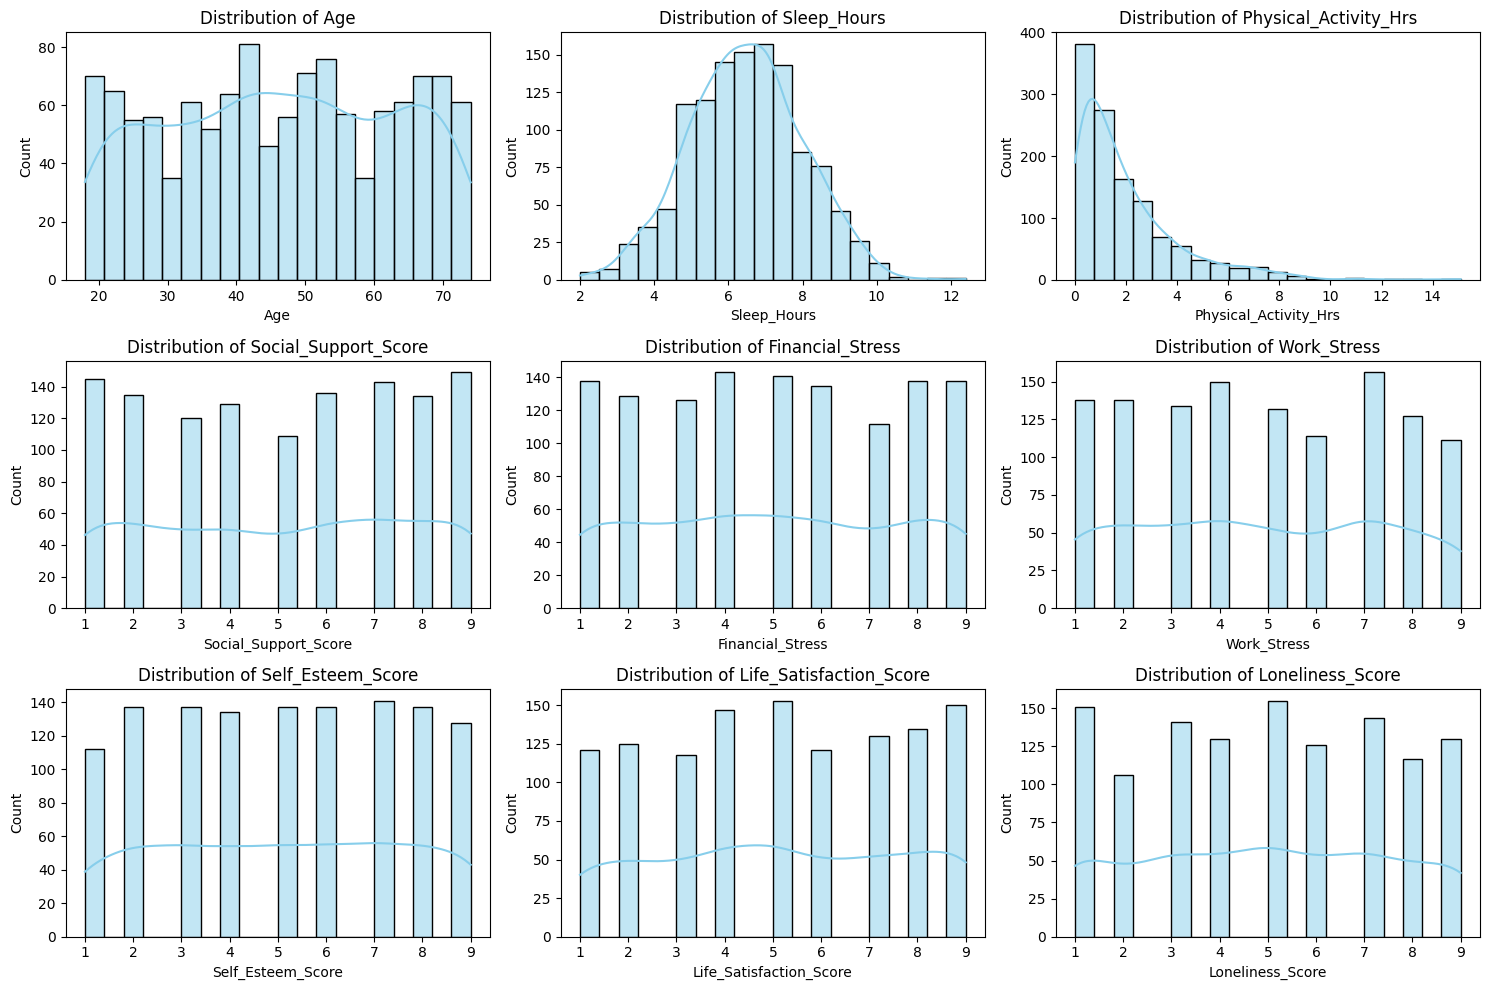

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = [
    'Age', 'Sleep_Hours', 'Physical_Activity_Hrs', 'Social_Support_Score',
    'Financial_Stress', 'Work_Stress', 'Self_Esteem_Score', 'Life_Satisfaction_Score', 'Loneliness_Score'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue', bins=20)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


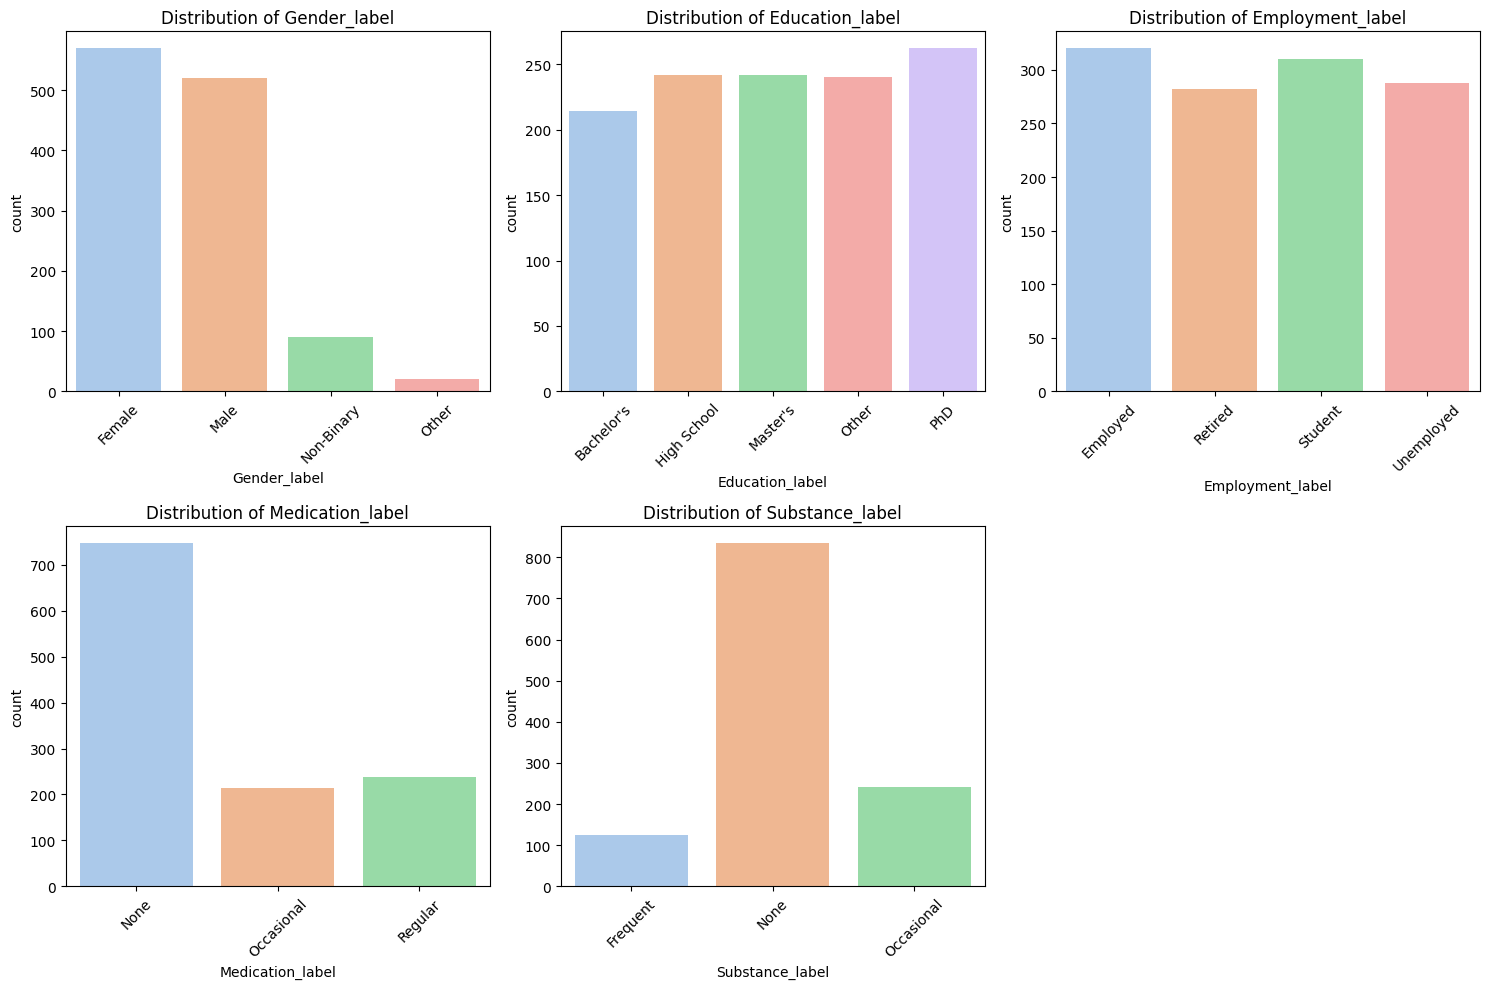

In [12]:
# --- Mapping numeric codes to category names ---
gender_labels = {0:'Male', 1:'Female', 2:'Non-Binary', 3:'Other'}
edu_labels = {0:'High School', 1:"Bachelor's", 2:"Master's", 3:'PhD', 4:'Other'}
emp_labels = {0:'Unemployed', 1:'Retired', 2:'Employed', 3:'Student'}
med_labels = {0:'None', 1:'Occasional', 2:'Regular'}
sub_labels = {0:'None', 1:'Occasional', 2:'Frequent'}

df['Gender_label'] = df['Gender'].map(gender_labels)
df['Education_label'] = df['Education_Level'].map(edu_labels)
df['Employment_label'] = df['Employment_Status'].map(emp_labels)
df['Medication_label'] = df['Medication_Use'].map(med_labels)
df['Substance_label'] = df['Substance_Use'].map(sub_labels)

# --- Categorical features with readable labels ---
categorical_features = ['Gender_label', 'Education_label', 'Employment_label',
                        'Medication_label', 'Substance_label']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_features):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=col, data=df, palette='pastel')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


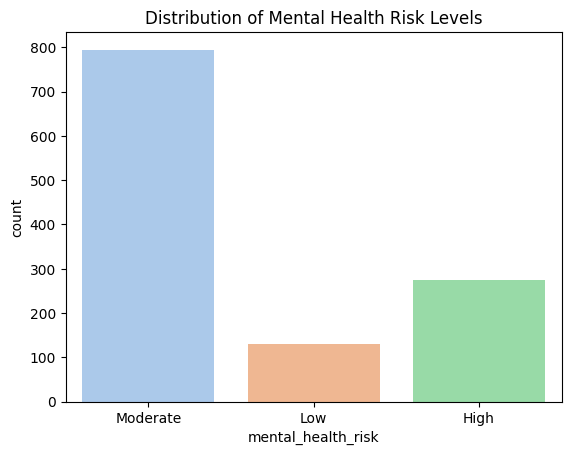

In [13]:
sns.countplot(x='mental_health_risk', data=df, palette='pastel')
plt.title("Distribution of Mental Health Risk Levels")
plt.show()

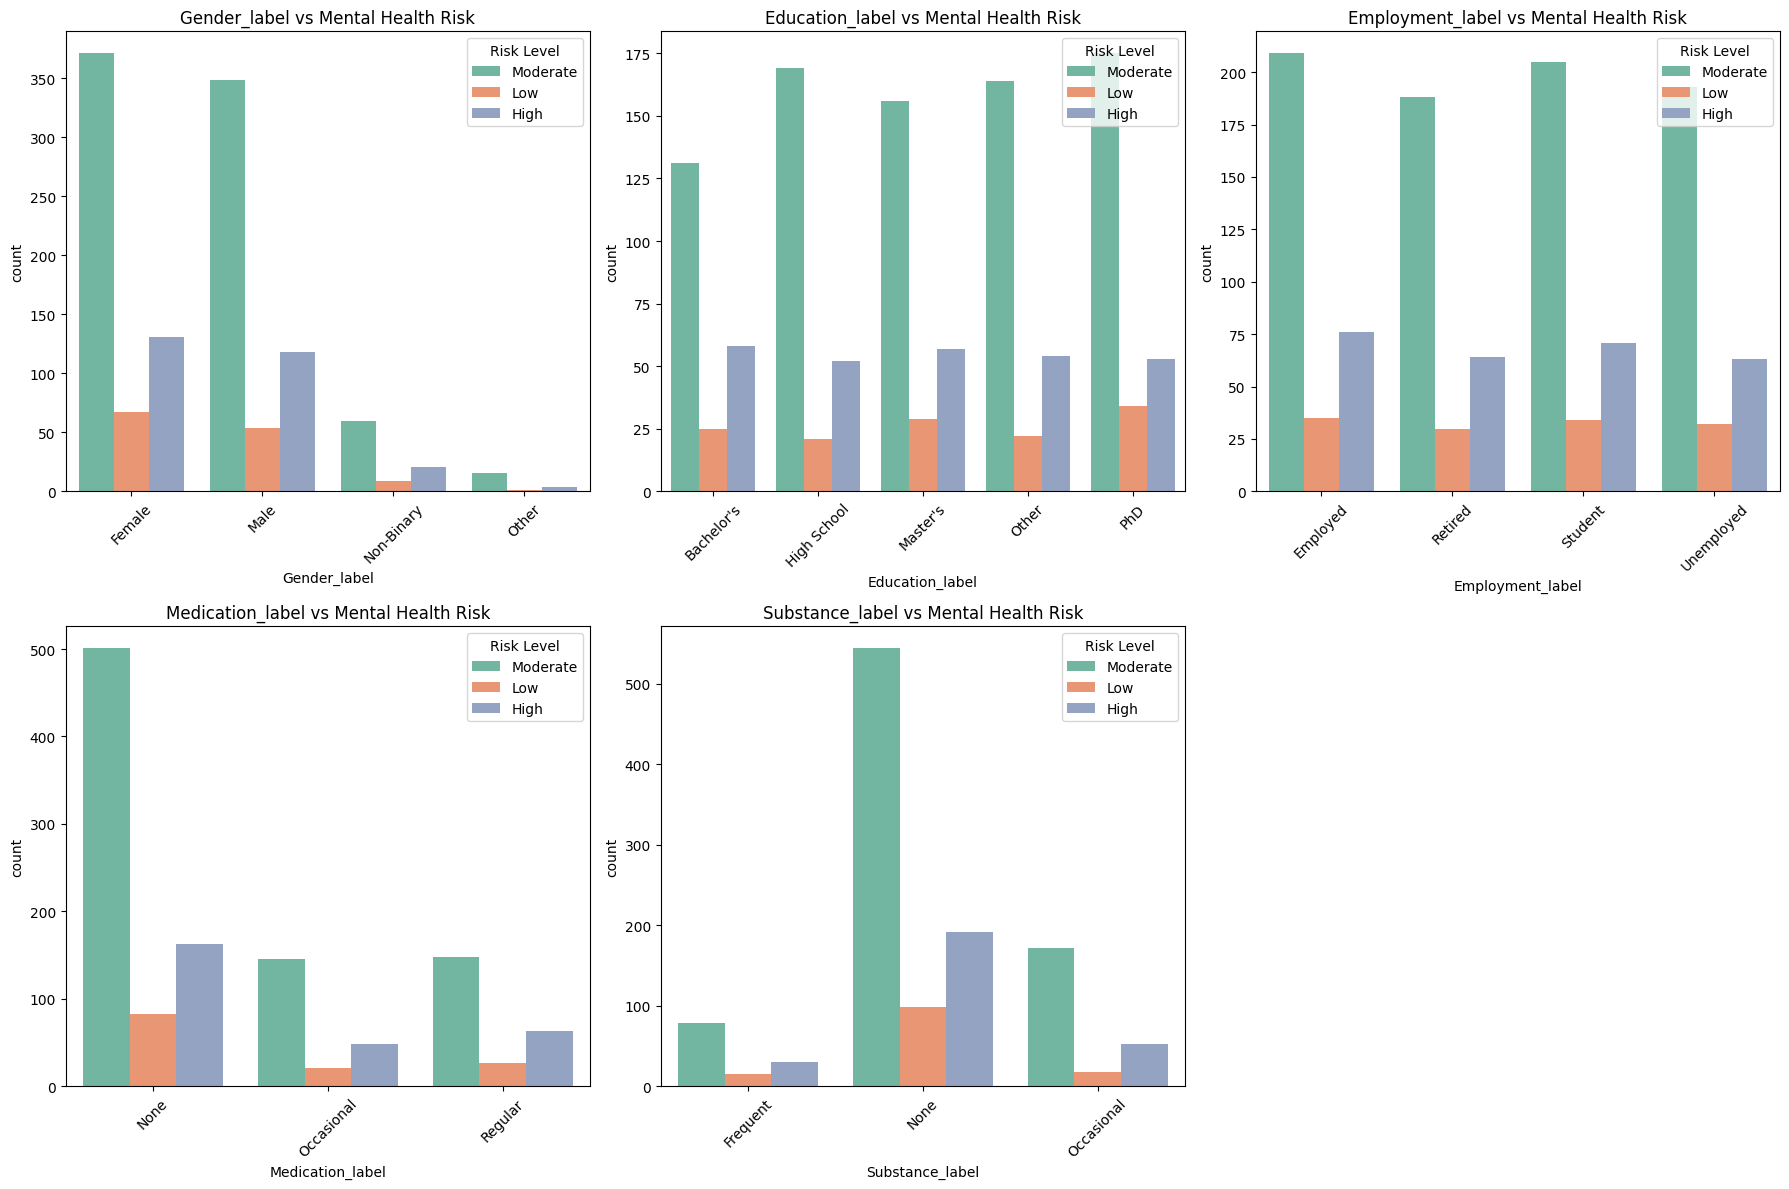

In [14]:
plt.figure(figsize=(18, 12))

categorical_features_labels = [
    'Gender_label',
    'Education_label',
    'Employment_label',
    'Medication_label',
    'Substance_label'
]

for i, col in enumerate(categorical_features_labels):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=col, hue='mental_health_risk', data=df, palette='Set2')
    plt.title(f'{col} vs Mental Health Risk')
    plt.xticks(rotation=45)
    plt.legend(title='Risk Level')

plt.tight_layout()
plt.show()

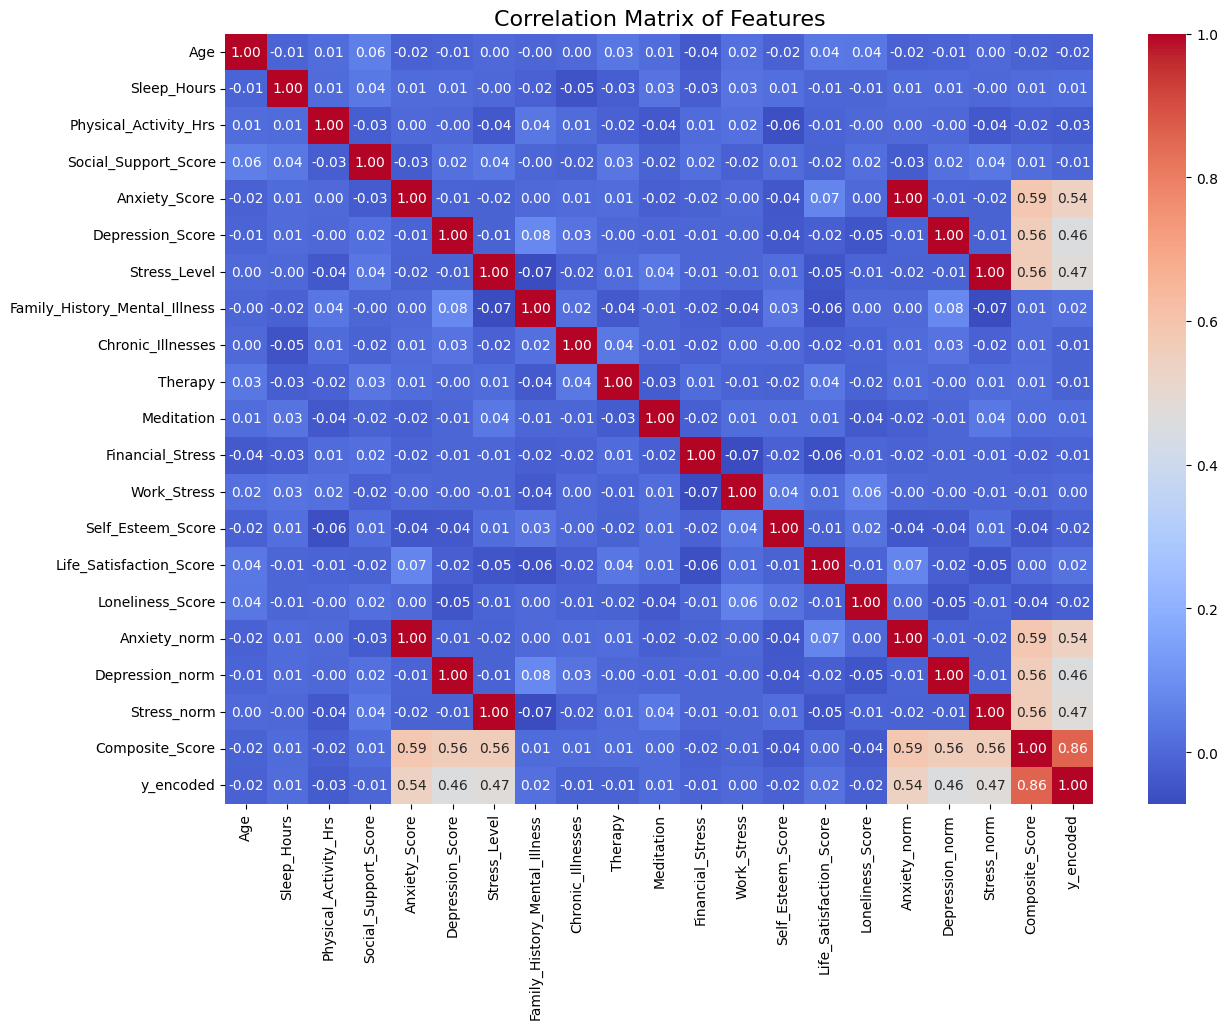

In [15]:
plt.figure(figsize=(14,10))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()


In [16]:
numeric_cols = ['Sleep_Hours','Physical_Activity_Hrs','Social_Support_Score',
                'Anxiety_Score','Depression_Score','Stress_Level','Financial_Stress',
                'Work_Stress','Self_Esteem_Score','Life_Satisfaction_Score','Loneliness_Score']
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers | Lower bound={lower:.2f} | Upper bound={upper:.2f}")


Sleep_Hours: 6 outliers | Lower bound=2.25 | Upper bound=10.65
Physical_Activity_Hrs: 75 outliers | Lower bound=-2.55 | Upper bound=5.85
Social_Support_Score: 0 outliers | Lower bound=-3.00 | Upper bound=13.00
Anxiety_Score: 0 outliers | Lower bound=-11.50 | Upper bound=32.50
Depression_Score: 0 outliers | Lower bound=-7.50 | Upper bound=28.50
Stress_Level: 0 outliers | Lower bound=-3.00 | Upper bound=13.00
Financial_Stress: 0 outliers | Lower bound=-3.00 | Upper bound=13.00
Work_Stress: 0 outliers | Lower bound=-3.00 | Upper bound=13.00
Self_Esteem_Score: 0 outliers | Lower bound=-3.00 | Upper bound=13.00
Life_Satisfaction_Score: 0 outliers | Lower bound=-3.00 | Upper bound=13.00
Loneliness_Score: 0 outliers | Lower bound=-3.00 | Upper bound=13.00


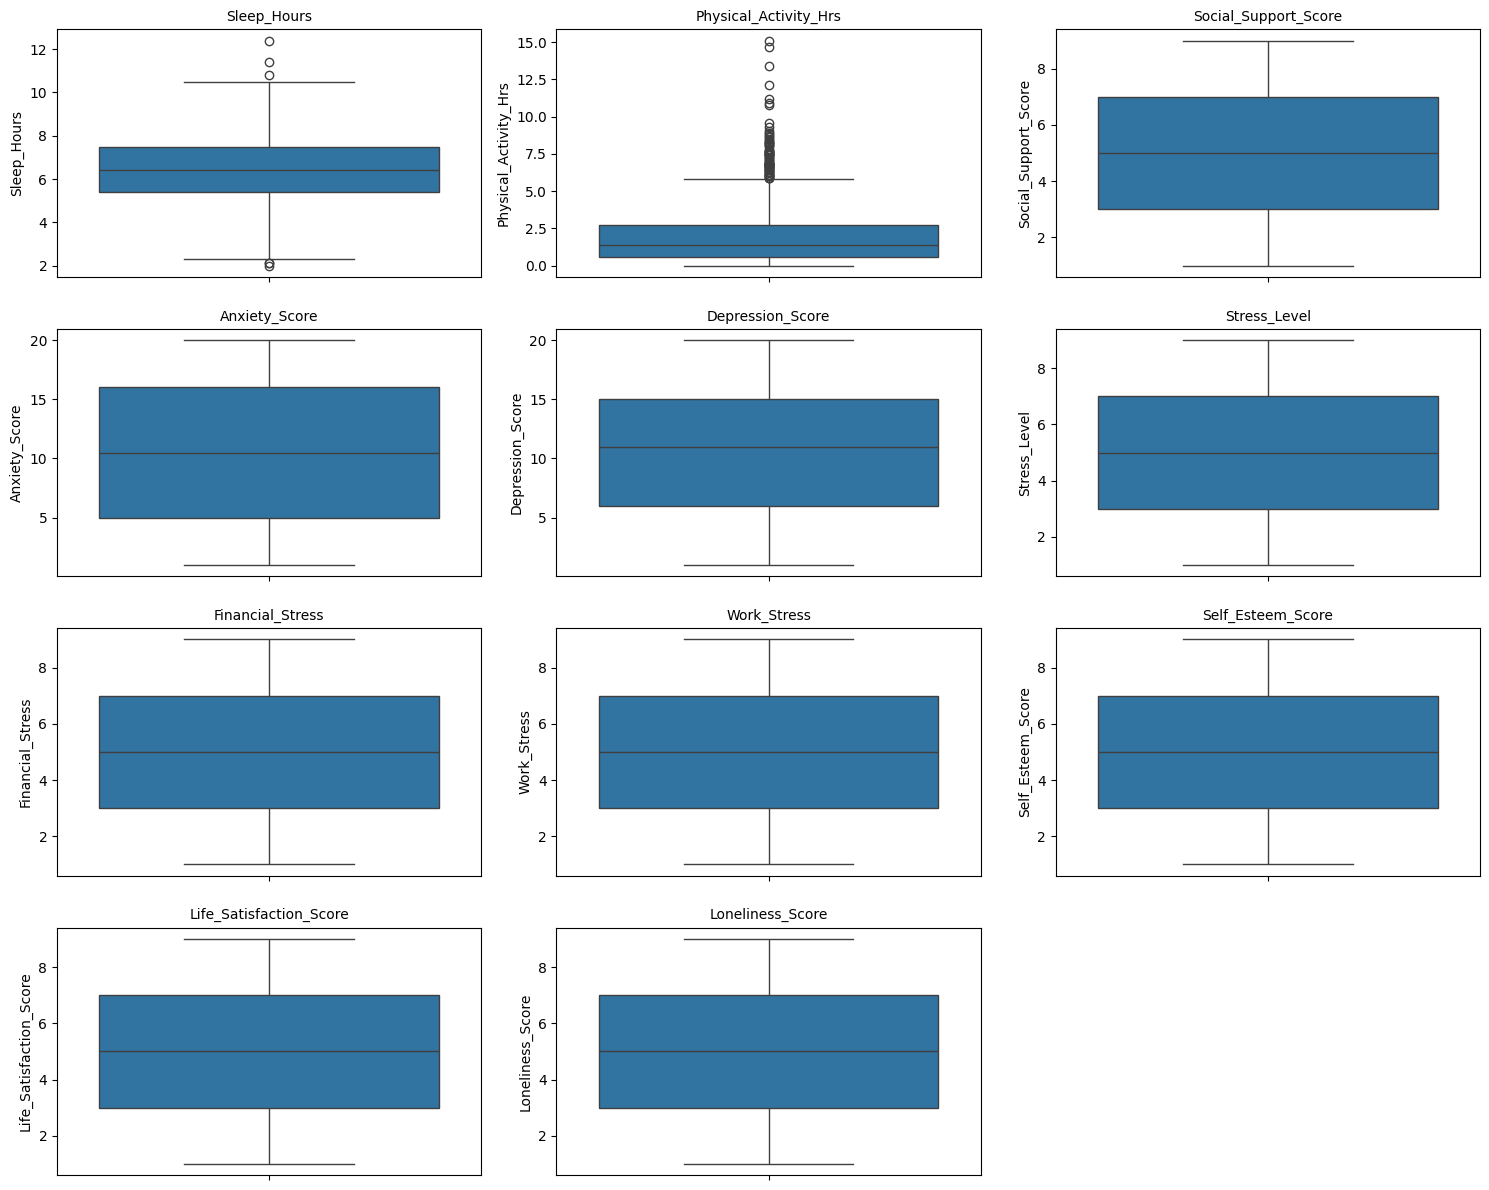

In [17]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col, fontsize=10, rotation=0)
plt.tight_layout(h_pad=2)
plt.show()


✅ Dataset shape after outlier removal: (1120, 32)


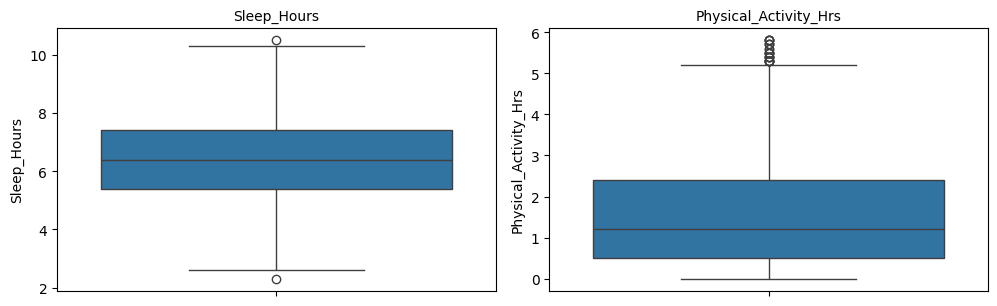

In [18]:
# Columns with outliers
outlier_cols = ['Sleep_Hours', 'Physical_Activity_Hrs']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter the DataFrame to keep only rows within bounds
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"✅ Dataset shape after outlier removal: {df.shape}")
plt.figure(figsize=(15, 12))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col, fontsize=10, rotation=0)
plt.tight_layout(h_pad=2)
plt.show()


In [19]:
df.columns

Index(['Age', 'Gender', 'Education_Level', 'Employment_Status', 'Sleep_Hours',
       'Physical_Activity_Hrs', 'Social_Support_Score', 'Anxiety_Score',
       'Depression_Score', 'Stress_Level', 'Family_History_Mental_Illness',
       'Chronic_Illnesses', 'Medication_Use', 'Therapy', 'Meditation',
       'Substance_Use', 'Financial_Stress', 'Work_Stress', 'Self_Esteem_Score',
       'Life_Satisfaction_Score', 'Loneliness_Score', 'Anxiety_norm',
       'Depression_norm', 'Stress_norm', 'Composite_Score',
       'mental_health_risk', 'y_encoded', 'Gender_label', 'Education_label',
       'Employment_label', 'Medication_label', 'Substance_label'],
      dtype='object')

In [20]:
df.dtypes

,0
Age,int64
Gender,category
Education_Level,category
Employment_Status,category
Sleep_Hours,float64
Physical_Activity_Hrs,float64
Social_Support_Score,int64
Anxiety_Score,int64
Depression_Score,int64
Stress_Level,int64


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --------------------------
# 1. Define features (X) and target (y)
# --------------------------
X = df.drop(columns=[
    'Anxiety_Score', 'Depression_Score', 'Stress_Level',
    'Anxiety_norm', 'Depression_norm', 'Stress_norm',
    'Composite_Score', 'mental_health_risk', 'y_encoded',
    'Gender_label', 'Education_label', 'Employment_label',
    'Medication_label', 'Substance_label'
])

y = df['y_encoded']

# --------------------------
# 2. Train-Test Split
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Training samples:", X_train.shape[0])
print("✅ Testing samples:", X_test.shape[0])

# --------------------------
# 3. Feature Scaling (optional)
# --------------------------
# Only scale numeric features (not categorical encodings)
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# --------------------------
# 4. Preview
# --------------------------
print("\nX_train sample:")
print(X_train.head())
print("\ny_train sample:")
print(y_train.head())

✅ Training samples: 896
✅ Testing samples: 224

X_train sample:
          Age Gender Education_Level Employment_Status  Sleep_Hours  \
272  1.360315      1               2                 3     0.293377   
870  1.054902      0               4                 3    -0.781190   
108 -0.899741      0               2                 2     0.494859   
910  0.505159      0               3                 1     1.233624   
354 -0.716494      1               1                 1    -0.042425   

     Physical_Activity_Hrs  Social_Support_Score  \
272               0.430028             -0.436968   
870              -0.529727              1.076165   
108              -0.234418              0.697882   
910               1.315955              0.319599   
354               2.644847              1.076165   

     Family_History_Mental_Illness  Chronic_Illnesses Medication_Use  \
272                      -0.688247          -0.594537              2   
870                      -0.688247           1.68198


--- Logistic Regression ---
Accuracy: 0.6652
Classification Report:
               precision    recall  f1-score   support

         Low       0.00      0.00      0.00        24
    Moderate       0.67      1.00      0.80       149
        High       0.00      0.00      0.00        51

    accuracy                           0.67       224
   macro avg       0.22      0.33      0.27       224
weighted avg       0.44      0.67      0.53       224



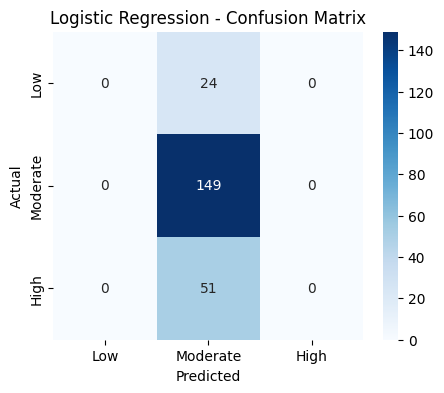


--- Random Forest ---
Accuracy: 0.6562
Classification Report:
               precision    recall  f1-score   support

         Low       0.00      0.00      0.00        24
    Moderate       0.66      0.99      0.79       149
        High       0.00      0.00      0.00        51

    accuracy                           0.66       224
   macro avg       0.22      0.33      0.26       224
weighted avg       0.44      0.66      0.53       224



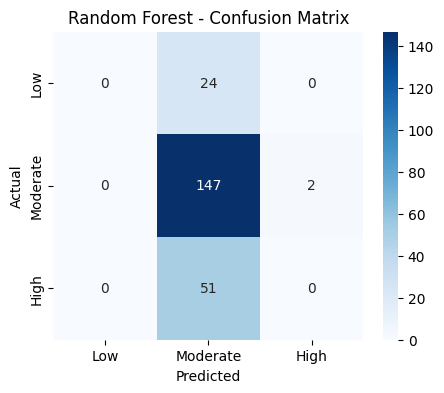


--- MLP Classifier ---
Accuracy: 0.5357
Classification Report:
               precision    recall  f1-score   support

         Low       0.12      0.08      0.10        24
    Moderate       0.66      0.73      0.69       149
        High       0.21      0.18      0.19        51

    accuracy                           0.54       224
   macro avg       0.33      0.33      0.33       224
weighted avg       0.50      0.54      0.52       224



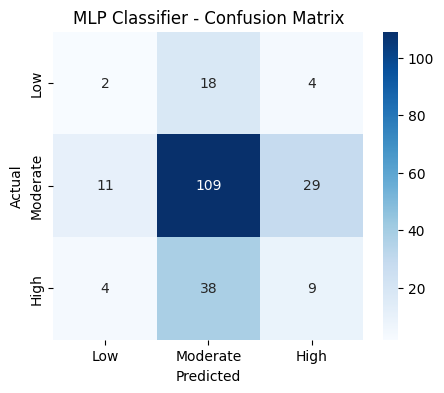

In [22]:
# --------------------------
# 1. Import libraries
# --------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------
# 2. Initialize models
# --------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "MLP Classifier": MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500, random_state=42)
}

# --------------------------
# 3. Train and evaluate each model
# --------------------------
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Classification report
    report = classification_report(y_test, y_pred, target_names=['Low','Moderate','High'])

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Save results
    results[name] = {"accuracy": acc, "report": report, "confusion_matrix": cm}

    # Print results
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:\n", report)

    # Plot confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','Moderate','High'], yticklabels=['Low','Moderate','High'])
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Logistic Regression with class weights
log_reg_bal = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
log_reg_bal.fit(X_train, y_train)
y_pred_lr = log_reg_bal.predict(X_test)

print("=== Logistic Regression (Balanced Class Weights) ===")
print(classification_report(y_test, y_pred_lr, target_names=['Low','Moderate','High']))

# Random Forest with class weights
rf_bal = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_bal.fit(X_train, y_train)
y_pred_rf = rf_bal.predict(X_test)

print("=== Random Forest (Balanced Class Weights) ===")
print(classification_report(y_test, y_pred_rf, target_names=['Low','Moderate','High']))

=== Logistic Regression (Balanced Class Weights) ===
              precision    recall  f1-score   support

         Low       0.08      0.25      0.12        24
    Moderate       0.71      0.35      0.47       149
        High       0.22      0.33      0.27        51

    accuracy                           0.33       224
   macro avg       0.34      0.31      0.29       224
weighted avg       0.53      0.33      0.39       224

=== Random Forest (Balanced Class Weights) ===
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        24
    Moderate       0.67      1.00      0.80       149
        High       0.00      0.00      0.00        51

    accuracy                           0.67       224
   macro avg       0.22      0.33      0.27       224
weighted avg       0.44      0.67      0.53       224



✅ After SMOTENC, class distribution in training set:
y_encoded
1    594
2    594
0    594
Name: count, dtype: int64
NaN values in X_train_res after SMOTENC: 0

=== Random Forest (SMOTENC Oversampling) ===
              precision    recall  f1-score   support

         Low       0.06      0.04      0.05        24
    Moderate       0.68      0.86      0.76       149
        High       0.11      0.04      0.06        51

    accuracy                           0.58       224
   macro avg       0.28      0.31      0.29       224
weighted avg       0.49      0.58      0.52       224



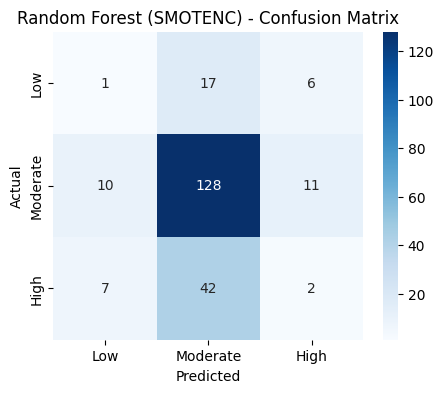


=== Logistic Regression (SMOTENC Oversampling) ===
              precision    recall  f1-score   support

         Low       0.04      0.08      0.05        24
    Moderate       0.68      0.60      0.64       149
        High       0.16      0.14      0.15        51

    accuracy                           0.44       224
   macro avg       0.30      0.27      0.28       224
weighted avg       0.50      0.44      0.46       224



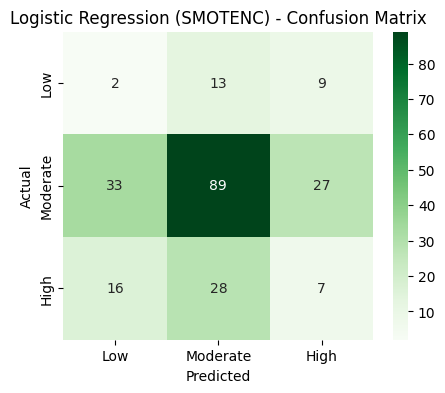

In [24]:
# --------------------------
# 1. Import SMOTENC
# --------------------------
from imblearn.over_sampling import SMOTENC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Identify categorical features for SMOTENC
# List all columns in X_train
all_cols_in_X = X_train.columns.tolist()
# Define numeric columns that were scaled
numeric_cols_scaled = [
    'Age', 'Sleep_Hours', 'Physical_Activity_Hrs', 'Social_Support_Score',
    'Financial_Stress', 'Work_Stress', 'Self_Esteem_Score',
    'Life_Satisfaction_Score', 'Loneliness_Score'
]
# Categorical columns are those in X_train that are not numeric and scaled
categorical_cols_for_smotenc_names = [col for col in all_cols_in_X if col not in numeric_cols_scaled]
categorical_features_indices = [all_cols_in_X.index(col) for col in categorical_cols_for_smotenc_names]

# --------------------------
# 2. Apply SMOTENC to training data
# --------------------------
smote = SMOTENC(categorical_features=categorical_features_indices, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("✅ After SMOTENC, class distribution in training set:")
print(y_train_res.value_counts())
# Verify no NaN values were introduced by SMOTENC
print(f"NaN values in X_train_res after SMOTENC: {X_train_res.isnull().sum().sum()}")

# --------------------------
# 3. Train Random Forest on SMOTENC data
# --------------------------
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_res, y_train_res)
y_pred_rf = rf_smote.predict(X_test)

print("\n=== Random Forest (SMOTENC Oversampling) ===")
print(classification_report(y_test, y_pred_rf, target_names=['Low','Moderate','High']))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','Moderate','High'], yticklabels=['Low','Moderate','High'])
plt.title("Random Forest (SMOTENC) - Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --------------------------
# 4. Train Logistic Regression on SMOTENC data
# --------------------------
log_reg_smote = LogisticRegression(max_iter=500, random_state=42)
log_reg_smote.fit(X_train_res, y_train_res)
y_pred_lr = log_reg_smote.predict(X_test)

print("\n=== Logistic Regression (SMOTENC Oversampling) ===")
print(classification_report(y_test, y_pred_lr, target_names=['Low','Moderate','High']))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=['Low','Moderate','High'], yticklabels=['Low','Moderate','High'])
plt.title("Logistic Regression (SMOTENC) - Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [25]:
!pip install xgboost

Fitting 3 folds for each of 162 candidates, totalling 486 fits
✅ Best parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1}

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

         Low       0.14      0.08      0.11        24
    Moderate       0.66      0.81      0.73       149
        High       0.29      0.16      0.20        51

    accuracy                           0.58       224
   macro avg       0.36      0.35      0.35       224
weighted avg       0.52      0.58      0.54       224



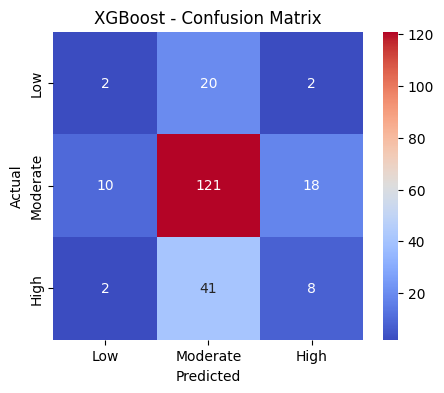

In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# 1. Define the XGBoost classifier with class weights
# --------------------------
# Compute class weights manually
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

xgb = XGBClassifier(
    objective='multi:softmax',   # multi-class classification
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=1,  # for multi-class, we will use sample_weight in fit
    enable_categorical=True # Enable native handling of categorical features
)

# --------------------------
# 2. Hyperparameter tuning using GridSearchCV
# --------------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9, 1],
    'colsample_bytree': [0.7, 0.9, 1]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',  # optimize for macro F1 (good for imbalanced)
    cv=3,
    verbose=1,
    n_jobs=-1
)

# --------------------------
# 3. Fit the model using class weights
# --------------------------
# Create a sample_weight array based on class weights
sample_weights = y_train.map(class_weights_dict)

grid.fit(X_train, y_train, sample_weight=sample_weights)

print("✅ Best parameters:", grid.best_params_)

# --------------------------
# 4. Evaluate on test set
# --------------------------
best_xgb = grid.best_estimator_
y_pred = best_xgb.predict(X_test)

print("\n=== XGBoost Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Low','Moderate','High']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=['Low','Moderate','High'], yticklabels=['Low','Moderate','High'])
plt.title("XGBoost - Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

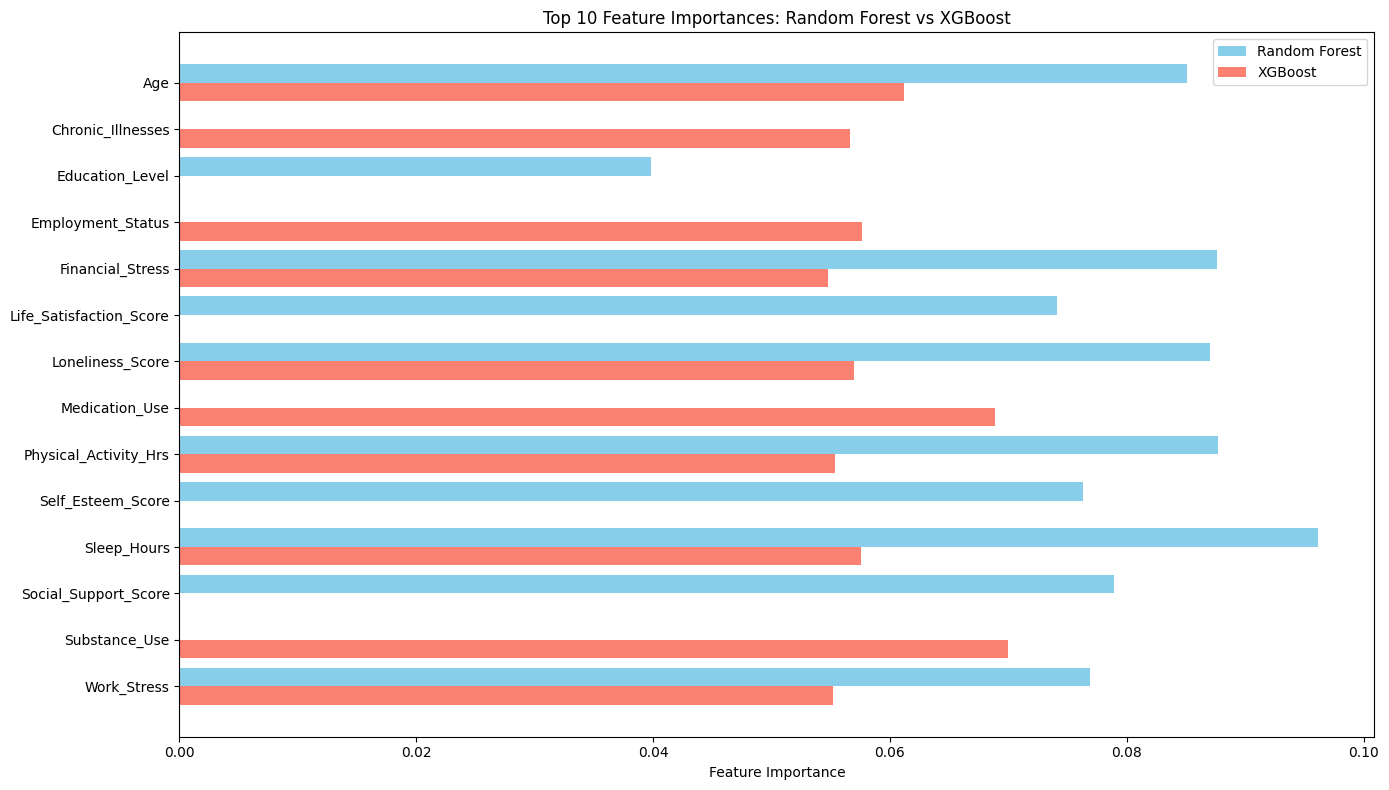

In [27]:
# Get top 10 features for each model
top_n = 10

# Get feature importances for Random Forest (rf_smote)
rf_importances = rf_smote.feature_importances_
feat_imp_rf_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_importances})
feat_imp_rf_df = feat_imp_rf_df.sort_values(by='Importance', ascending=False)

# Get feature importances for XGBoost (best_xgb)
xgb_importances = best_xgb.feature_importances_
feat_imp_xgb_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb_importances})
feat_imp_xgb_df = feat_imp_xgb_df.sort_values(by='Importance', ascending=False)

top_rf = feat_imp_rf_df.head(top_n).copy()
top_xgb = feat_imp_xgb_df.head(top_n).copy() # Use feat_imp_xgb_df for XGBoost

# Merge for plotting
merged_df = pd.merge(top_rf, top_xgb, on='Feature', how='outer', suffixes=('_RF', '_XGB')).fillna(0)

# Plot
plt.figure(figsize=(14,8))

# Bar positions
indices = np.arange(len(merged_df))

# Width of bars
width = 0.4

# Plot RF importance
plt.barh(indices - width/2, merged_df['Importance_RF'], height=width, color='skyblue', label='Random Forest')

# Plot XGB importance
plt.barh(indices + width/2, merged_df['Importance_XGB'], height=width, color='salmon', label='XGBoost')

# Labels
plt.yticks(indices, merged_df['Feature'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances: Random Forest vs XGBoost')
plt.gca().invert_yaxis()  # highest importance on top
plt.legend()
plt.tight_layout()
plt.show()

✅ psychological meaning
✅ behavioral influence
✅ clinical relevance

“Age emerged as one of the most influential predictors, likely reflecting the variation in psychological stressors across life stages. Younger individuals often face academic and social pressures, while older individuals may experience financial or health-related stress. This aligns with existing mental health research, increasing confidence in the model's interpretability.”

In [30]:
import joblib

# Categorical columns (encoded as integers)
categorical_columns = ['Gender', 'Education_Level', 'Employment_Status', 'Medication_Use', 'Substance_Use']

# Grab MLP from the models dict
mlp_model = models['MLP Classifier']

# Save bundle
bundle = {
    "model": best_xgb,
    "scaler": scaler,
    "feature_columns": X_train.columns.tolist(),
    "categorical_columns": categorical_columns
}

joblib.dump(bundle,        "mental_health_model_bundle.pkl")
joblib.dump(log_reg_smote, "lr_model.pkl")
joblib.dump(rf_smote,      "rf_model.pkl")
joblib.dump(mlp_model,     "mlp_model.pkl")

print("✅ All models saved successfully!")

✅ All models saved successfully!
